In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from astropy import constants as c
from scipy.integrate import quad
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit

In [ ]:
0

In [2]:
# import ROOT as r
# import warnings
# warnings.filterwarnings('ignore')

In [3]:
# r.gSystem.Load('$EVNDISPSYS/lib/libVAnaSum.so')

In [4]:
# filename = '/raid/reedbuck/lrizk/veritas/sources/UMa3/evndisp/muons/111645_muons.root'
# evndisp_file = r.TFile(filename)
# params = evndisp_file.Get('Tel_2/tpars')

In [5]:
# num_events = 0
# for event in params:
#     if event.muonValid and event.muonRadius:
#         num_events += 1

In [6]:
# real_muon_params = np.zeros((3, num_events))
# i = 0

# for event in params:
#     if event.muonValid and event.muonRadius:
#         real_muon_params[0][i] = event.muonRadius
#         real_muon_params[1][i] = event.muonRSigma
#         real_muon_params[2][i] = event.muonIPCorrectedSize
#         i += 1

In [7]:
# output = 'real_data/muons_111645.csv'
# np.savetxt(output, real_muon_params.T, delimiter=',')

In [1]:
real_data = 'real_data/muons_111645.csv'
muon_radii, muon_radii_err, muon_sizes = np.loadtxt(real_data, delimiter=',', unpack=True)

NameError: name 'np' is not defined

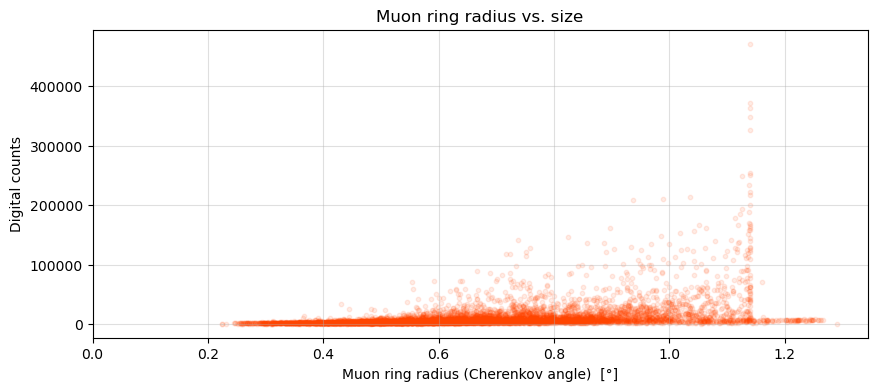

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.scatter(muon_radii, muon_sizes, c='orangered', marker='o', s=10, alpha=0.1)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)

plt.show()

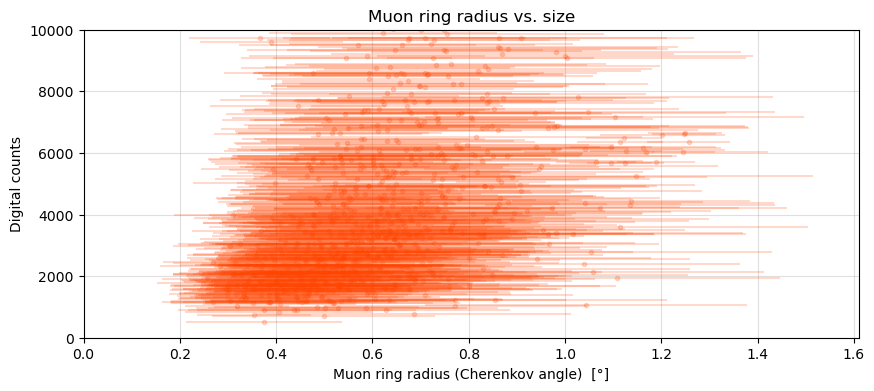

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.errorbar(x=muon_radii[:1000], xerr=muon_radii_err[:1000], y=muon_sizes[:1000],
             c='orangered', marker='o', ms=3, ls='', alpha=0.2)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(0, 1e4)

plt.show()

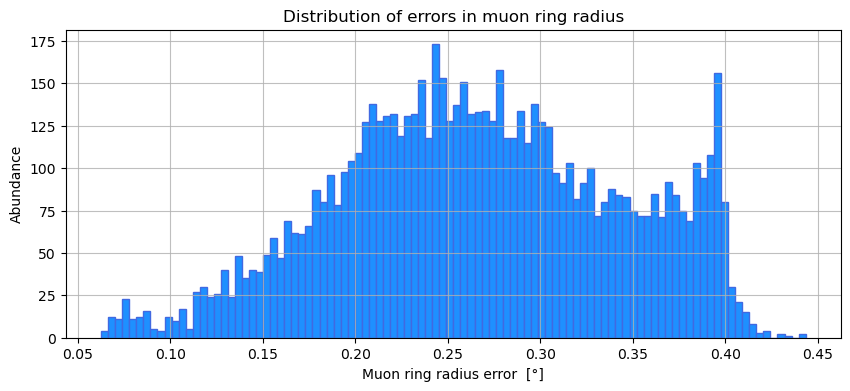

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

hist_data = plt.hist(muon_radii_err, bins=100, edgecolor='royalblue', color='dodgerblue')

plt.grid(alpha=0.8)
plt.xlabel('Muon ring radius error  [°]')
plt.ylabel('Abundance')
plt.title('Distribution of errors in muon ring radius')

plt.show()

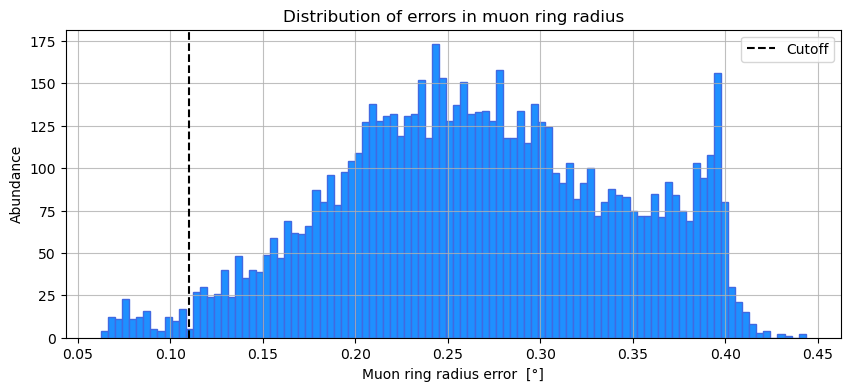

In [12]:
err_cutoff = 0.11

fig, ax = plt.subplots(figsize=(10, 4))

plt.hist(muon_radii_err, bins=100, edgecolor='royalblue', color='dodgerblue')
plt.axvline(x=err_cutoff, c='black', ls='--', label='Cutoff')

plt.grid(alpha=0.8)
plt.xlabel('Muon ring radius error  [°]')
plt.ylabel('Abundance')
plt.title('Distribution of errors in muon ring radius')

plt.legend()
plt.show()

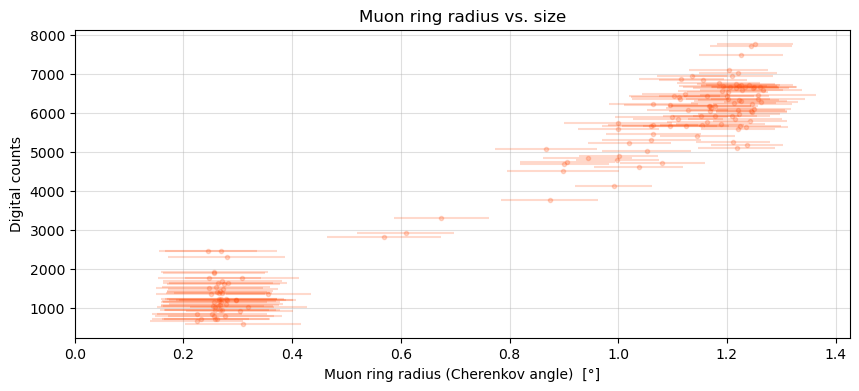

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.errorbar(x=muon_radii[muon_radii_err < err_cutoff], 
             xerr=muon_radii_err[muon_radii_err < err_cutoff],
             y=muon_sizes[muon_radii_err < err_cutoff],
             c='orangered', marker='o', ms=3, ls='', alpha=0.2)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
# plt.ylim(0, 1e4)

plt.show()

In [14]:
directory = 'output/'

muon_E_span = np.load(directory + 'muon_E.npy')
angles_deg = np.load(directory + 'ring_radii.npy')
true_ring_intensities = np.load(directory + 'muon_ring_sizes.npy')
true_ring_intensities_MM = np.load(directory + 'MM_ring_sizes.npy')

In [20]:
def linear(y, a, b):

    a_prime = 1/a
    b_prime = -b/a
    
    return a_prime * y + b_prime

In [21]:
theory_fit = curve_fit(
    linear, 
    ydata=angles_deg[angles_deg * true_ring_intensities > 0], 
    xdata=true_ring_intensities[angles_deg * true_ring_intensities > 0], 
    p0=[5000, 0])
theory_slope, theory_intercept = theory_fit[0]

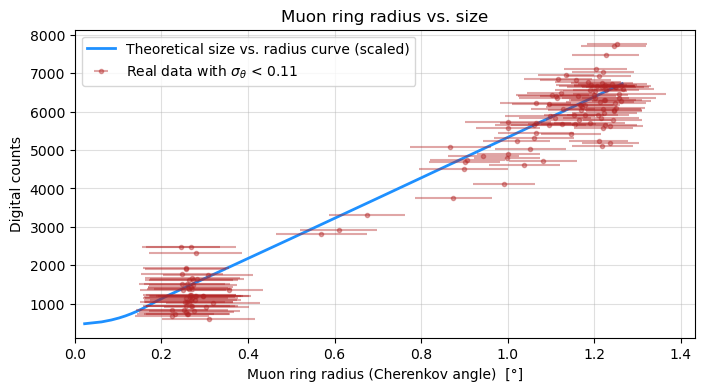

In [22]:
GAIN = 3  # (guess)

fig, ax = plt.subplots(figsize=(8, 4))

plt.plot(angles_deg, true_ring_intensities * GAIN, c='dodgerblue', lw=2,
         label='Theoretical size vs. radius curve (scaled)')

plt.errorbar(x=muon_radii[muon_radii_err < err_cutoff], 
             xerr=muon_radii_err[muon_radii_err < err_cutoff],
             y=muon_sizes[muon_radii_err < err_cutoff],
             c='firebrick', marker='o', ms=3, ls='', alpha=0.4,
             label=r'Real data with $\sigma_\theta$ < {}'.format(round(err_cutoff, 2)))

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
# plt.ylim(0, 1e4)

plt.legend()
plt.show()

In [23]:
fit = curve_fit(
    linear,
    xdata=muon_sizes[muon_radii_err < err_cutoff], 
    ydata=muon_radii[muon_radii_err < err_cutoff],
    sigma=muon_radii_err[muon_radii_err < err_cutoff], 
    absolute_sigma=True, 
    p0=[5000, 0],
)

In [24]:
slope, intercept = fit[0]
print('Real data slope:', slope)
print('Theory slope:', theory_slope)

Real data slope: 5689.748562911832
Theory slope: 1756.540221478367


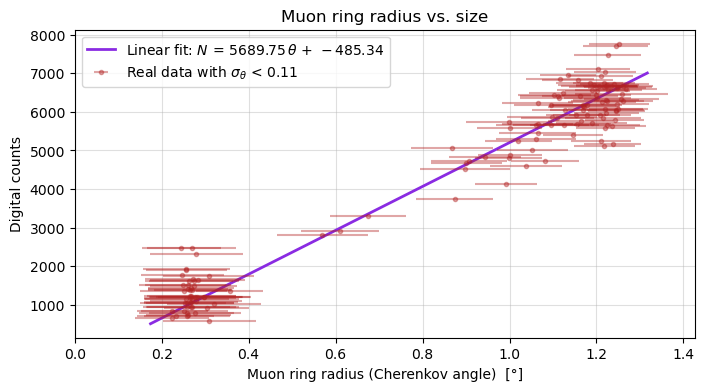

In [73]:
angles_range = np.linspace(
    np.min(muon_radii[muon_radii_err < err_cutoff]) - 0.05,
    np.max(muon_radii[muon_radii_err < err_cutoff]) + 0.05,
    1000
) 

fig, ax = plt.subplots(figsize=(8, 4))

plt.plot(angles_range, slope * angles_range + intercept, c='blueviolet', lw=2,
         label=r'Linear fit: $N \, = \, {} \, \theta \, + \, {}$'.format(
             round(slope, 2), 
             round(intercept, 2),
         ))

plt.errorbar(x=muon_radii[muon_radii_err < err_cutoff], 
             xerr=muon_radii_err[muon_radii_err < err_cutoff],
             y=muon_sizes[muon_radii_err < err_cutoff],
             c='firebrick', marker='o', ms=3, ls='', alpha=0.4,
             label=r'Real data with $\sigma_\theta$ < {}'.format(round(err_cutoff, 2)))

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
# plt.ylim(0, 1e4)

plt.legend()
plt.show()

In [77]:
# Chi2 test

model_guesses = linear(muon_sizes[muon_radii_err < err_cutoff], slope, intercept)

chi2 = np.sum((model_guesses - muon_radii[muon_radii_err < err_cutoff])**2 
              / (muon_radii_err[muon_radii_err < err_cutoff])**2)
dof = len(model_guesses) - 2
red_chi2 = chi2/dof
print(red_chi2)

1.3599719944235364


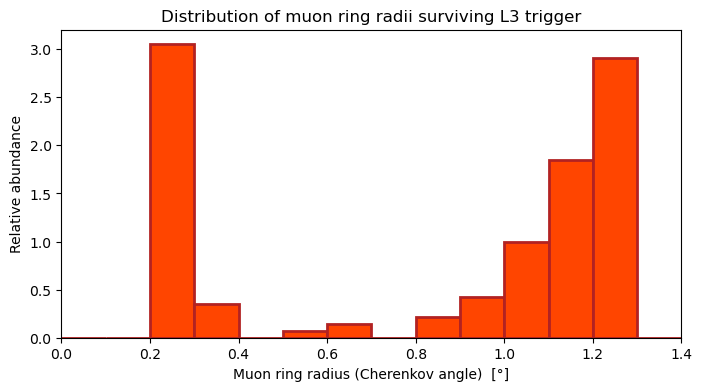

In [39]:
histobins = np.arange(0, 1.5, 0.1)

fig, ax = plt.subplots(figsize=(8, 4))

plt.hist(muon_radii[muon_radii_err < err_cutoff], bins=histobins, density=True,
         edgecolor='firebrick', lw=2, color='orangered')

plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Relative abundance')
plt.title('Distribution of muon ring radii surviving L3 trigger')

plt.xlim(histobins[0], histobins[-1])

plt.show()